In [2]:

# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np

import scienceplots

In [3]:


# # Step 2: Read the CSV file
# # Replace 'data.csv' with your actual CSV filename
# df = pd.read_csv('QGAN_training_history.csv')

# # Step 3: Convert seconds to minutes
# df['epoch_time_min'] = df['epoch_time_sec'] / 60

# # Step 4: (Optional) Drop the original seconds column if you don't need it
# df = df.drop(columns=['epoch_time_sec'])

# # Step 5: Save the modified CSV
# df.to_csv('QGAN_training.csv', index=False)

# # Step 6: Display the updated DataFrame
# df

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


Biểu đồ đã được lưu tại: training_times_comparison.pdf


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


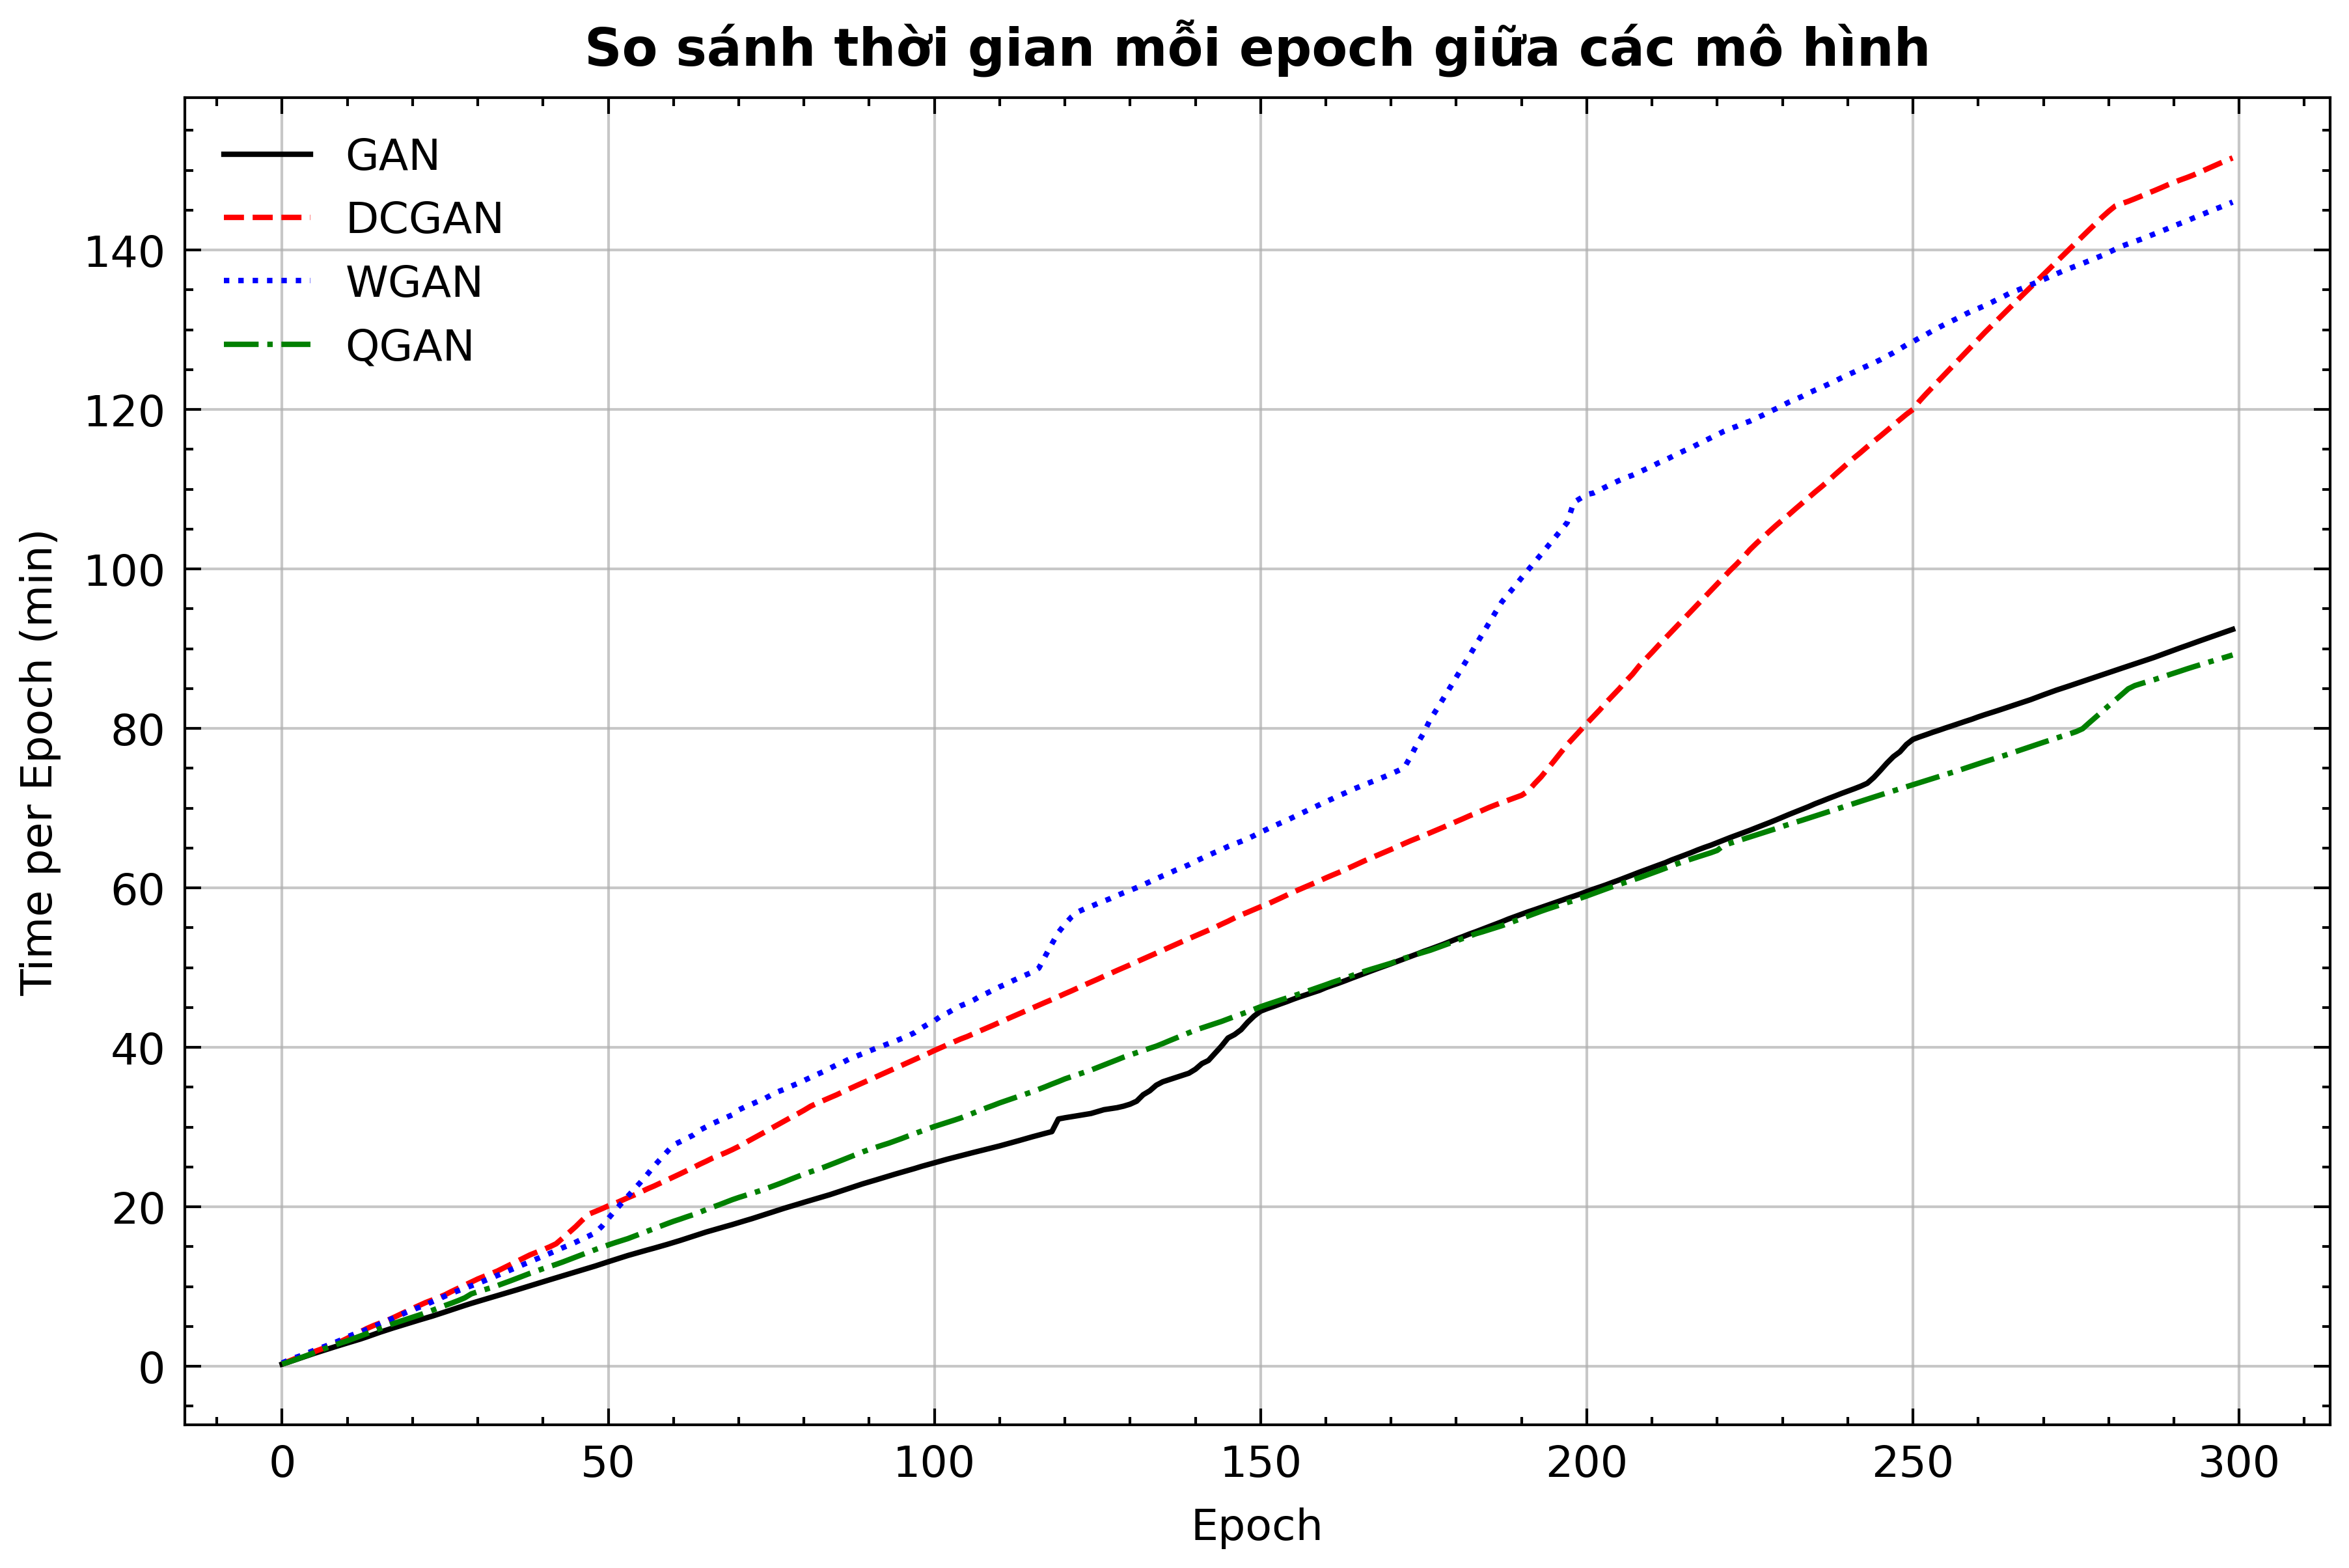

In [4]:
# Áp dụng style publication-ready
plt.style.use(['science', 'ieee'])

# Tắt rendering LaTeX (nếu không cần)
plt.rcParams['text.usetex'] = False

fig, ax = plt.subplots(constrained_layout=True, figsize=(6, 4))  # thêm constrained_layout
title = "So sánh thời gian mỗi epoch giữa các mô hình"

files = {
    'GAN': 'GAN_training.csv',
    'DCGAN': 'DCGAN_training.csv',
    'WGAN': 'WGAN_training.csv',
    'QGAN': 'QGAN_training.csv',
}

for label, filename in files.items():
    df = pd.read_csv(filename)
    ax.plot(df['epoch'], df['epoch_time_min'], label=label)

ax.set_xlabel('Epoch')
ax.set_ylabel('Time per Epoch (min)')
ax.set_title(title, fontweight='bold')
ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.7)
ax.legend(loc='upper left', ncol=1)

output_path = 'training_times_comparison.pdf'
plt.savefig(output_path, format='pdf', dpi=300)
print(f"Biểu đồ đã được lưu tại: {output_path}")

plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


Đã lưu biểu đồ tại: loss_C_vs_epoch_comparison.pdf


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


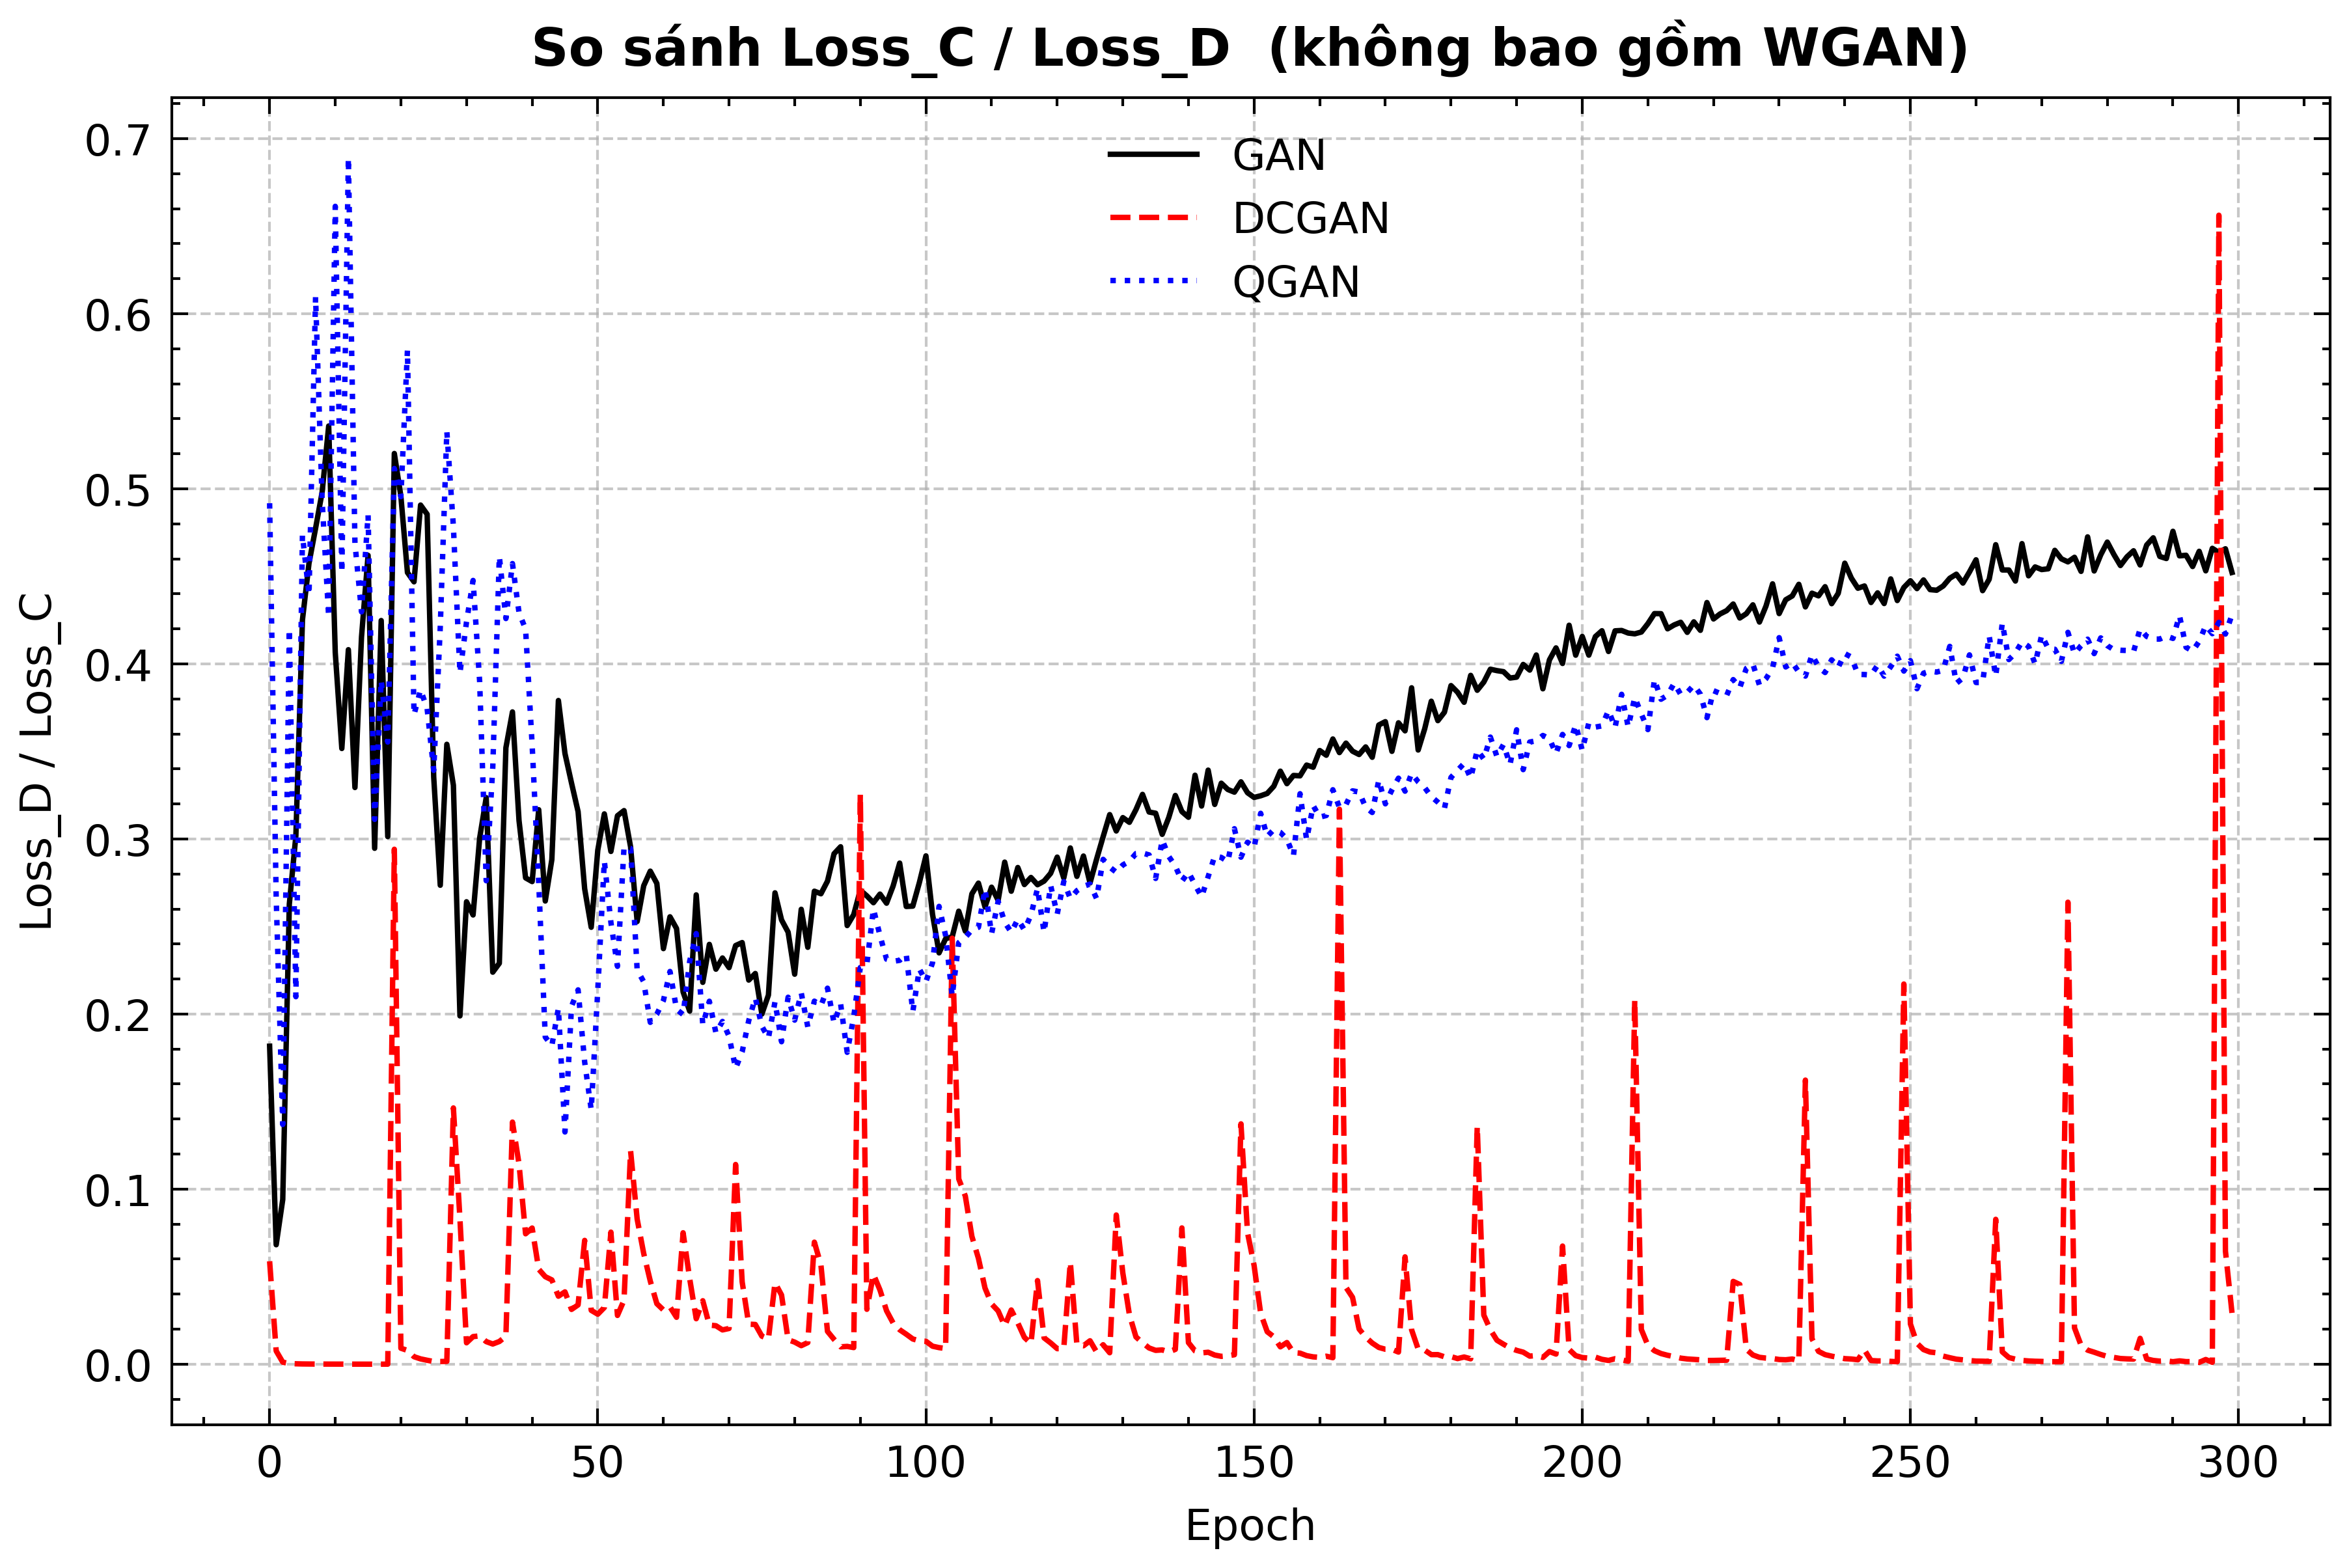

In [6]:
# Tạo figure với layout tự động
fig, ax = plt.subplots(constrained_layout=True, figsize=(6, 4))
title = "So sánh Loss_C / Loss_D  (không bao gồm WGAN)"

# Tên file và nhãn tương ứng
file_map = {
    'GAN': ('GAN_training.csv', 'loss_D'),
    'DCGAN': ('DCGAN_training.csv', 'loss_D'),
    'QGAN': ('QGAN_training.csv', 'loss_D'),
}

# Đọc và vẽ mỗi mô hình
for label, (filename, loss_col) in file_map.items():
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        print(f"Warning: Không tìm thấy file '{filename}'. Bỏ qua.")
        continue

    if 'epoch' not in df.columns or loss_col not in df.columns:
        print(f"Warning: File '{filename}' thiếu cột 'epoch' hoặc '{loss_col}'. Bỏ qua.")
        continue

    ax.plot(df['epoch'], df[loss_col], label=label)

# Nhãn, tiêu đề, lưới và chú giải
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss_D / Loss_C')
ax.set_title(title, fontweight='bold')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(loc='upper center')

# Lưu ảnh PDF (ở chuẩn xuất bản)
output_path = 'loss_C_vs_epoch_comparison.pdf'
plt.savefig(output_path, format='pdf', dpi=300)
print(f"Đã lưu biểu đồ tại: {output_path}")

plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


Đã lưu biểu đồ tại: loss_G_vs_epoch_comparison.pdf


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


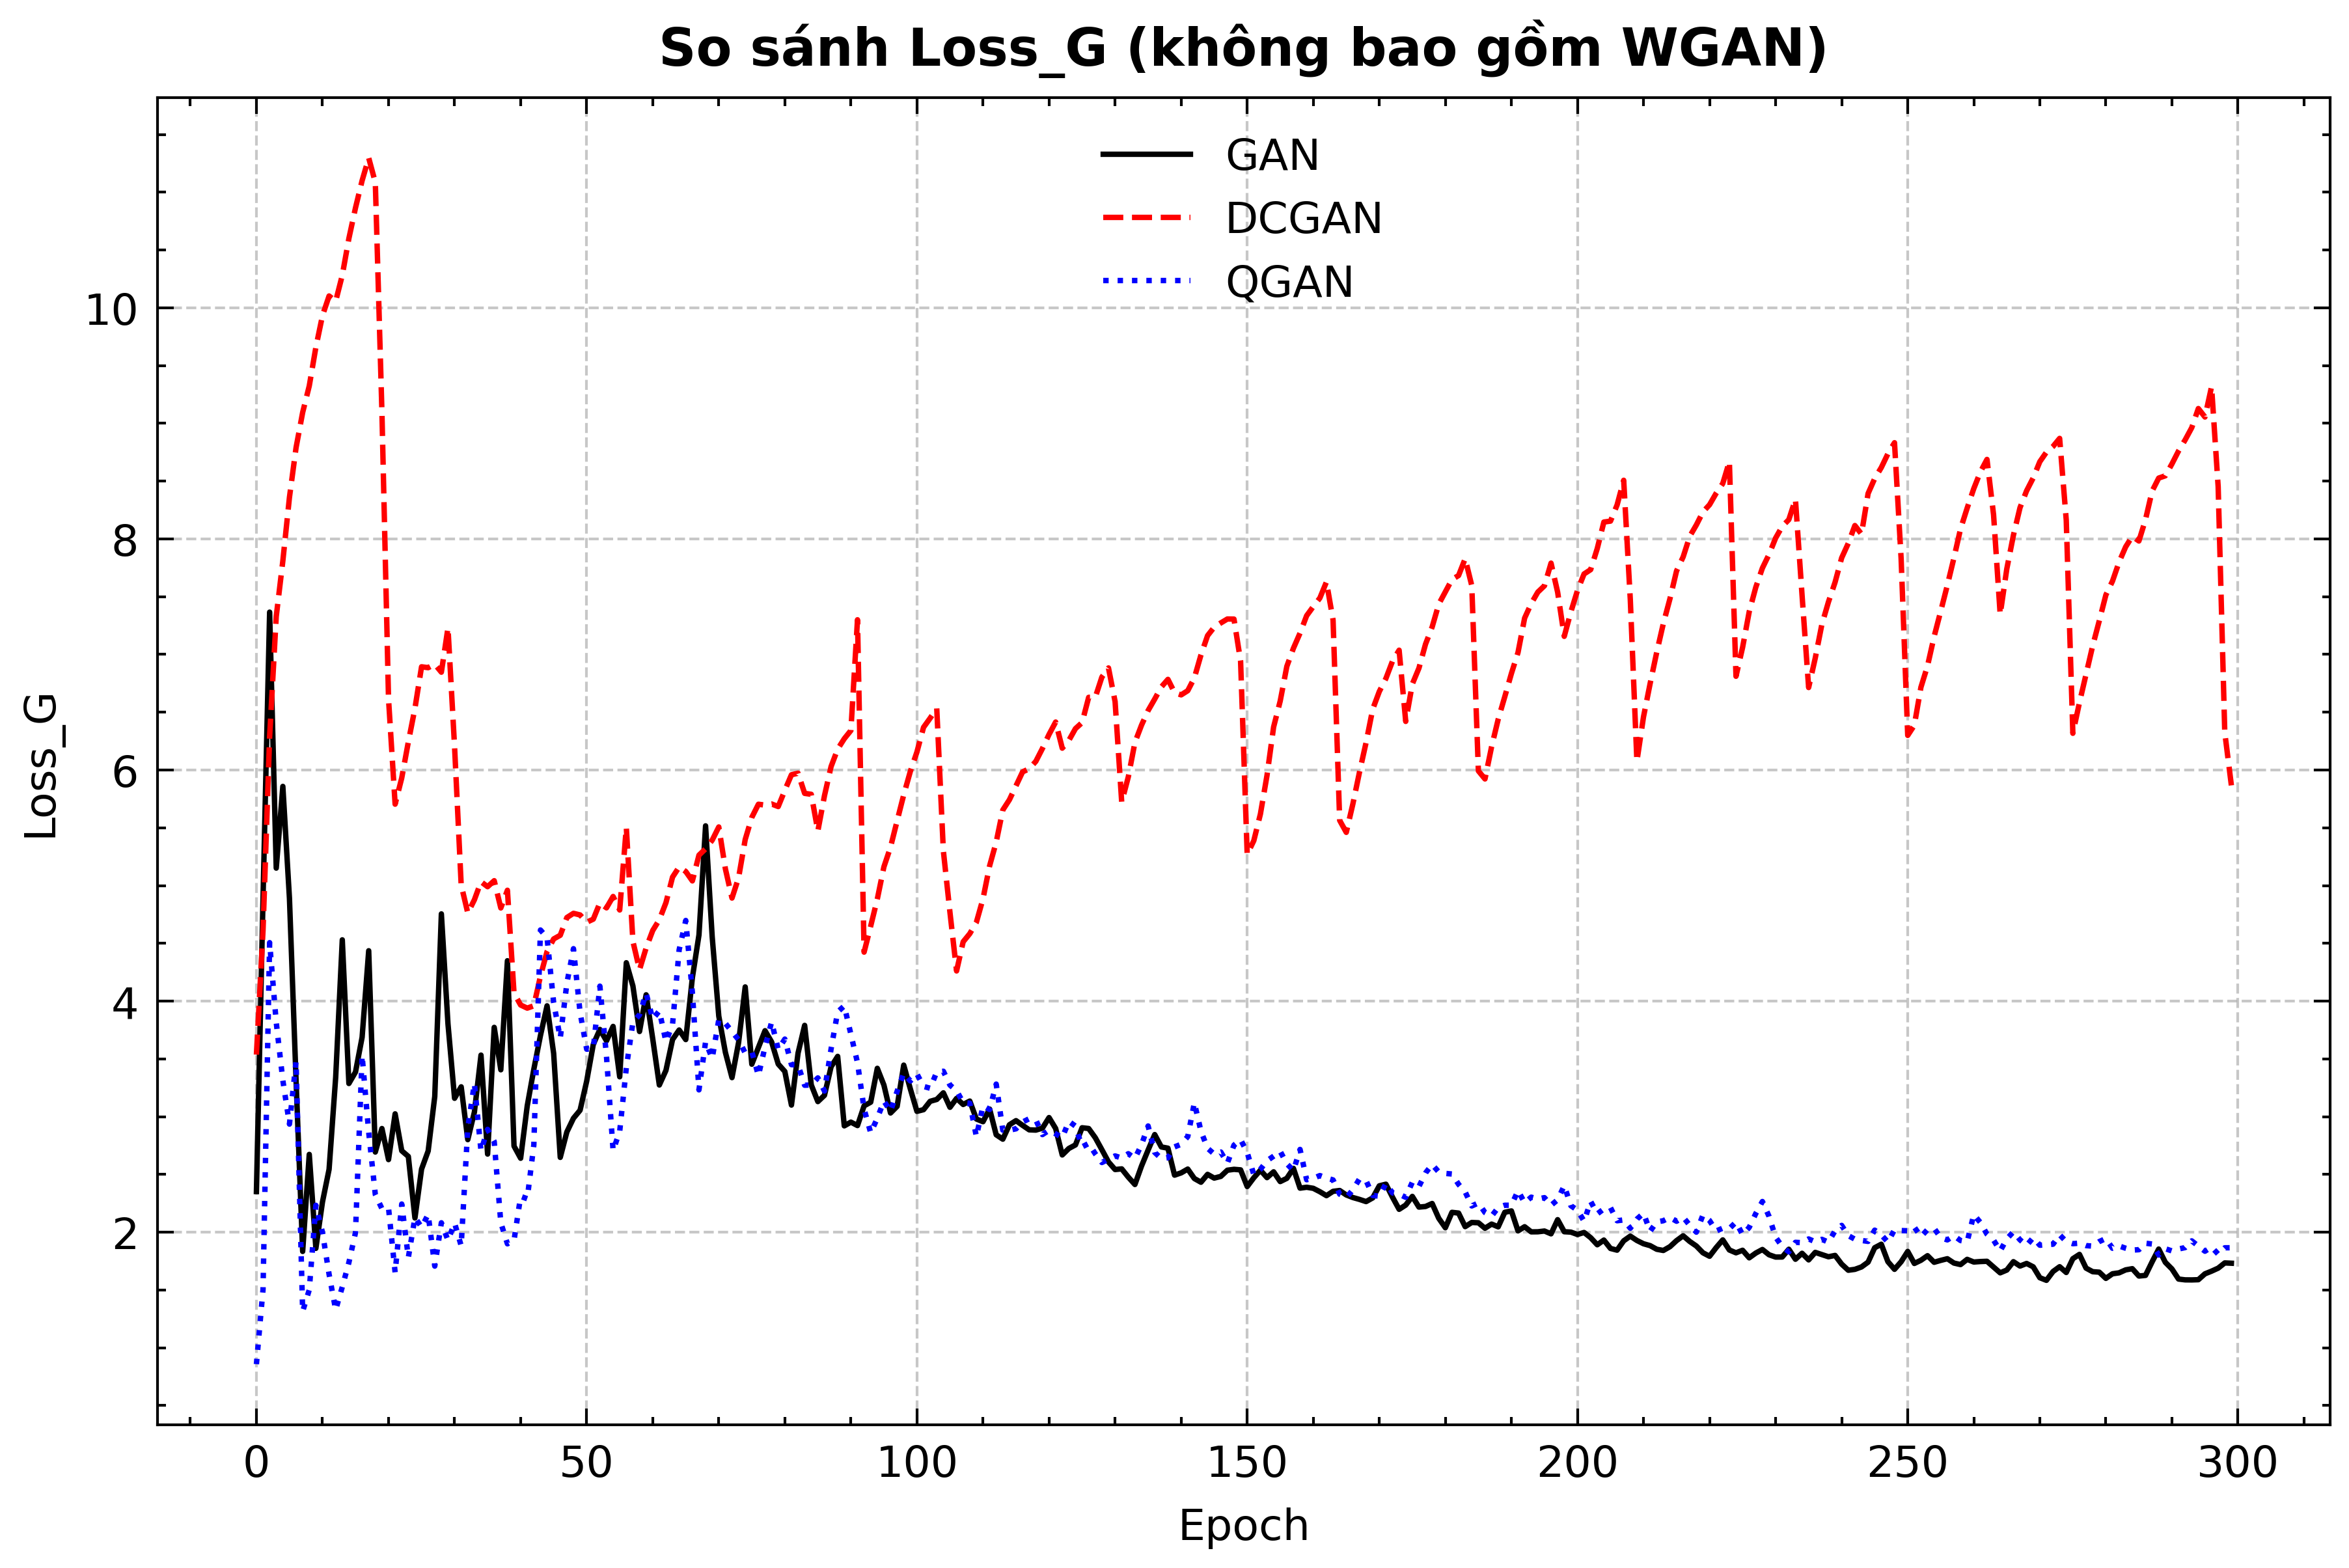

In [7]:
# Tạo figure với layout tự động
fig, ax = plt.subplots(constrained_layout=True, figsize=(6, 4))
title = "So sánh Loss_G (không bao gồm WGAN)"

# Tên file và nhãn tương ứng
file_map = {
    'GAN': ('GAN_training.csv', 'loss_G'),
    'DCGAN': ('DCGAN_training.csv', 'loss_G'),
    'QGAN': ('QGAN_training.csv', 'loss_G'),
}

# Đọc và vẽ mỗi mô hình
for label, (filename, loss_col) in file_map.items():
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        print(f"Warning: Không tìm thấy file '{filename}'. Bỏ qua.")
        continue

    if 'epoch' not in df.columns or loss_col not in df.columns:
        print(f"Warning: File '{filename}' thiếu cột 'epoch' hoặc '{loss_col}'. Bỏ qua.")
        continue

    ax.plot(df['epoch'], df[loss_col], label=label)

# Nhãn, tiêu đề, lưới và chú giải
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss_G')
ax.set_title(title, fontweight='bold')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(loc='upper center')

# Lưu ảnh PDF (ở chuẩn xuất bản)
output_path = 'loss_G_vs_epoch_comparison.pdf'
plt.savefig(output_path, format='pdf', dpi=300)
print(f"Đã lưu biểu đồ tại: {output_path}")

plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


Saved figure as: model_params_size_comparison_colorfix.pdf


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


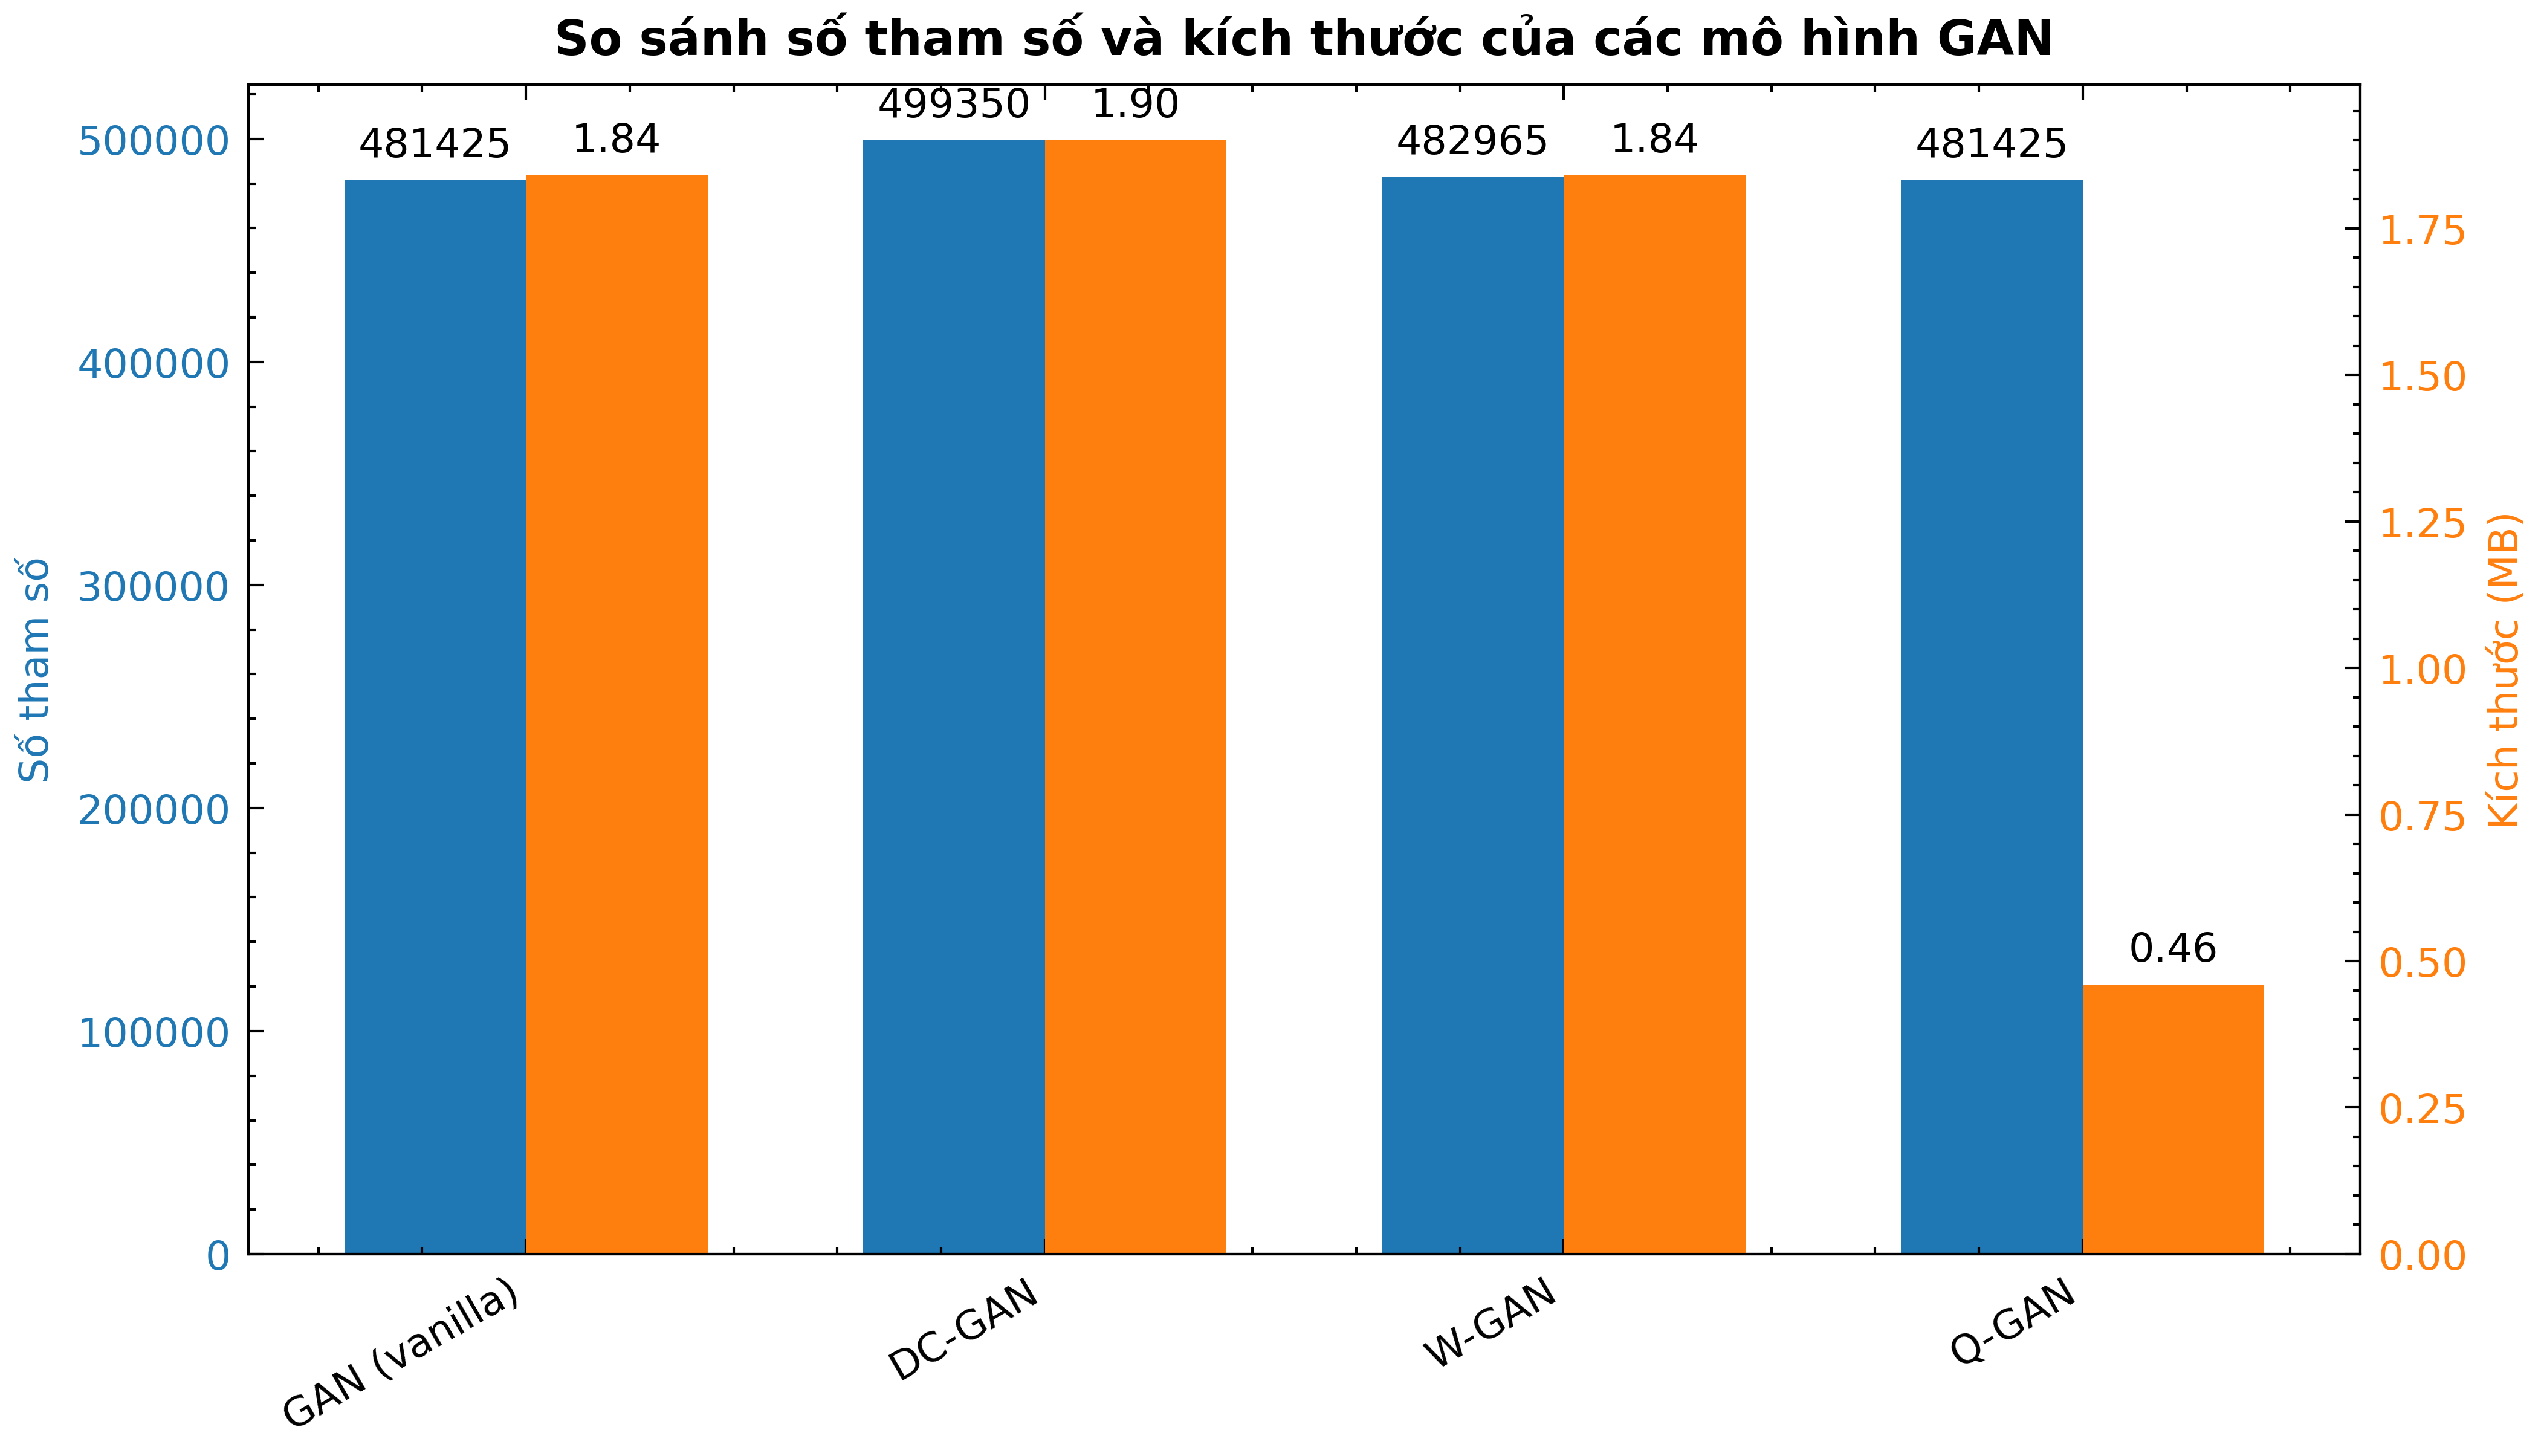

In [8]:
# Data
data = {
    'Model': ['GAN (vanilla)', 'DC-GAN', 'W-GAN', 'Q-GAN'],
    'Params': [481425, 499350, 482965, 481425],
    'Size_MB': [1.84, 1.90, 1.84, 0.46]
}
df = pd.DataFrame(data)

fig, ax1 = plt.subplots(constrained_layout=True, figsize=(7, 4))

x = np.arange(len(df['Model']))
width = 0.35

# Softer colors (blue + orange)
param_color = '#1f77b4'
size_color = '#ff7f0e'

# Bars
bars1 = ax1.bar(x - width/2, df['Params'], width, label='Số tham số', color=param_color)
ax1.set_ylabel('Số tham số', color=param_color)
ax1.tick_params(axis='y', labelcolor=param_color)

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, df['Size_MB'], width, label='Kích thước (MB)', color=size_color)
ax2.set_ylabel('Kích thước (MB)', color=size_color)
ax2.tick_params(axis='y', labelcolor=size_color)

ax1.set_xticks(x)
ax1.set_xticklabels(df['Model'], rotation=30, ha='right')
ax1.set_title('So sánh số tham số và kích thước của các mô hình GAN', fontweight='bold')

# Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines + lines2, labels + labels2, loc='upper right')

# Annotate bars
def annotate_bars(bars, ax, fmt="{:.2f}"):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(fmt.format(height),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

annotate_bars(bars1, ax1, fmt="{:.0f}")
annotate_bars(bars2, ax2, fmt="{:.2f}")

# Save & show
plt.savefig('model_params_size_comparison_colorfix.pdf', format='pdf', dpi=300)
print("Saved figure as: model_params_size_comparison_colorfix.pdf")

plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


✅ Saved GAN results to GAN_training_results.pdf


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


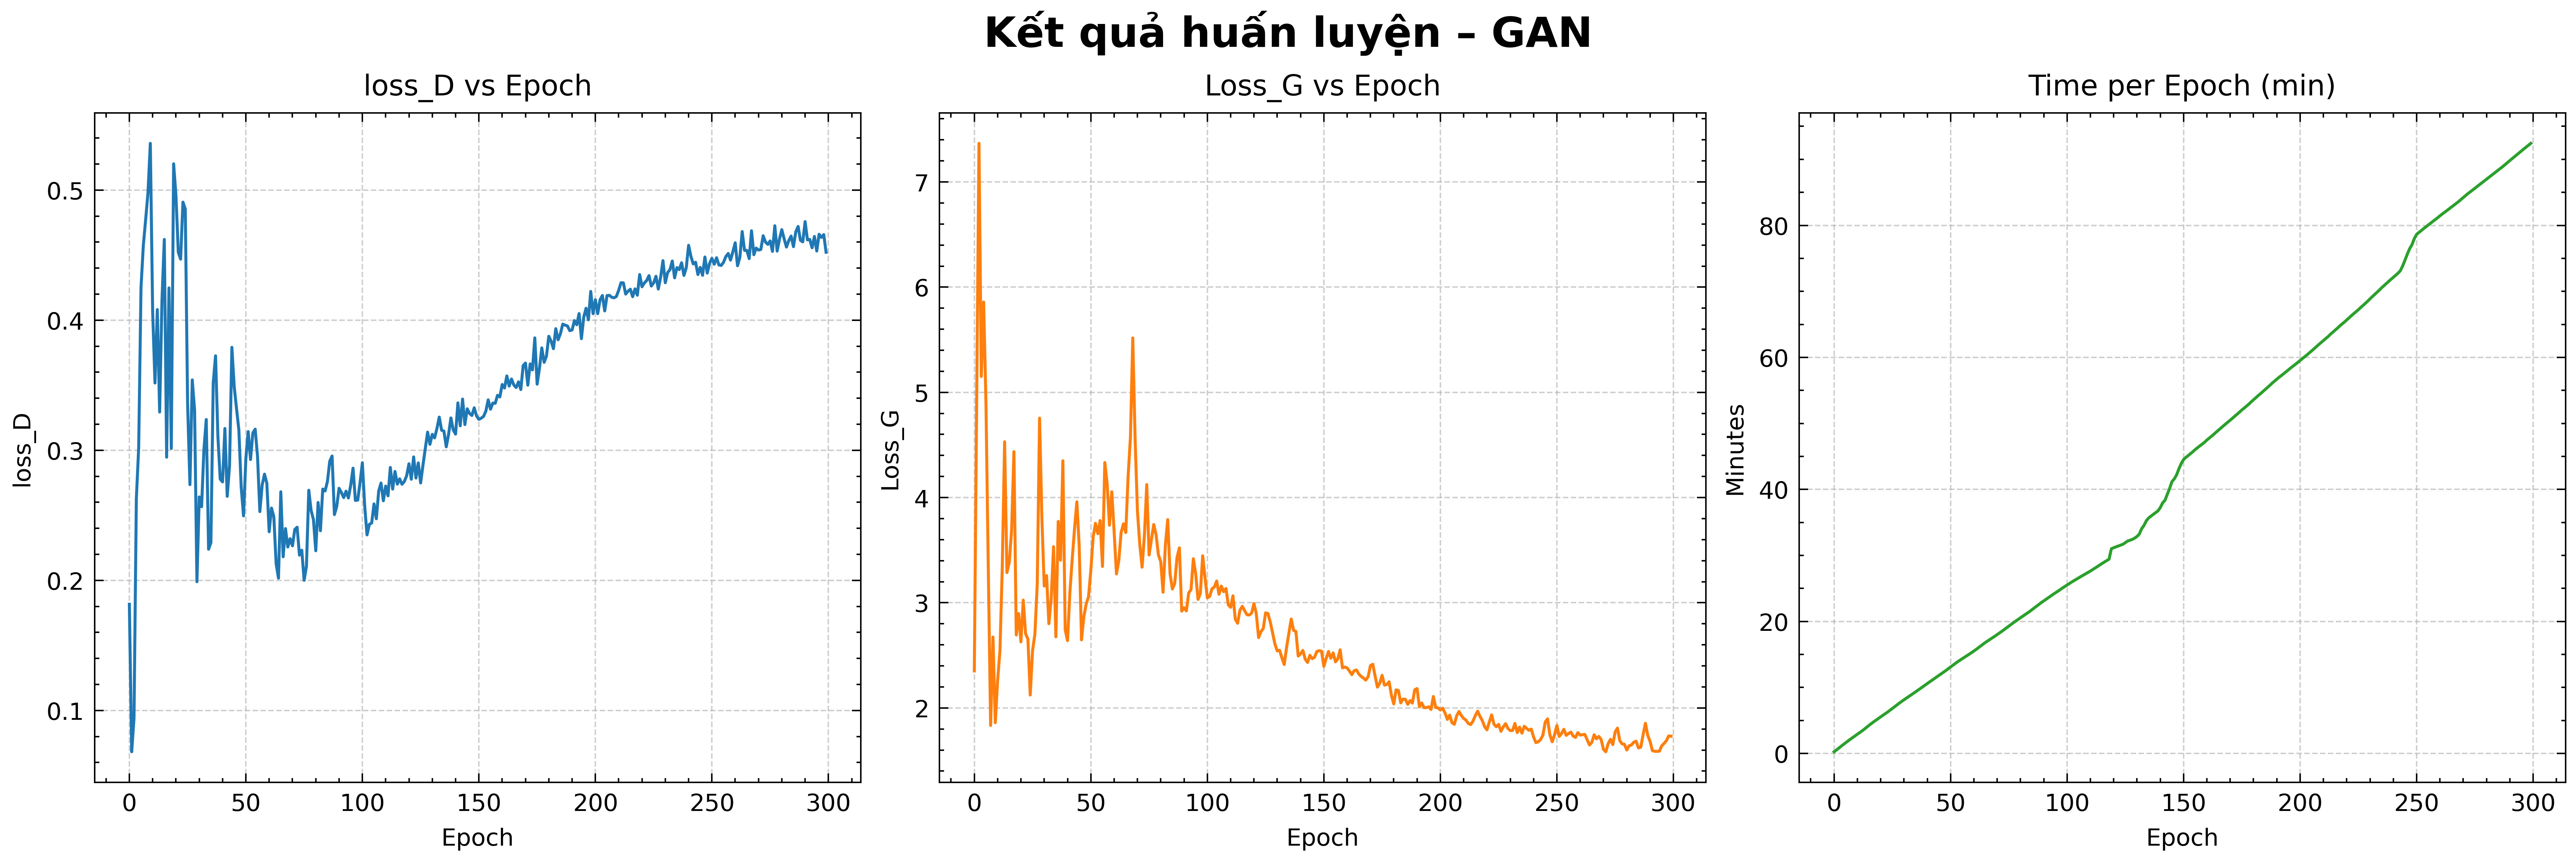

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


✅ Saved DCGAN results to DCGAN_training_results.pdf


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


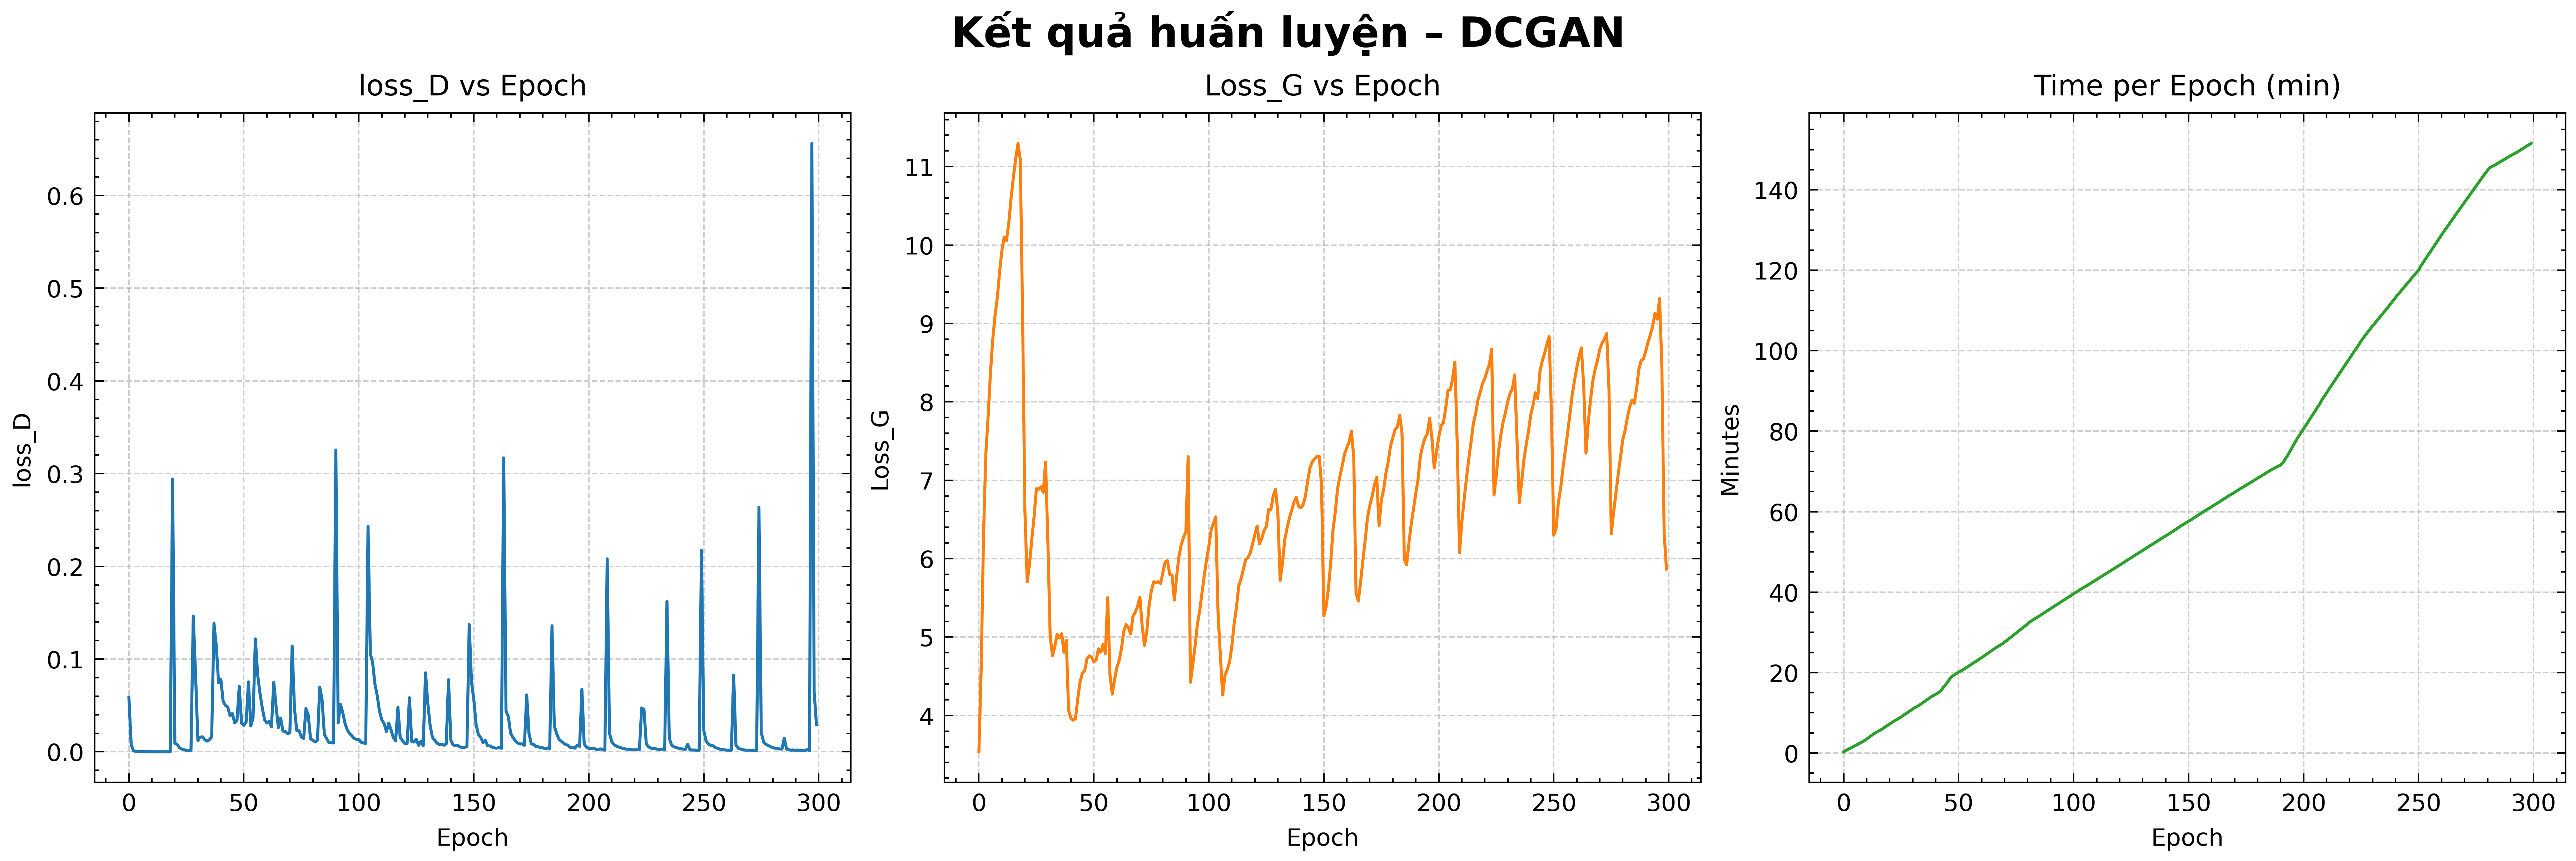

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


✅ Saved WGAN results to WGAN_training_results.pdf


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


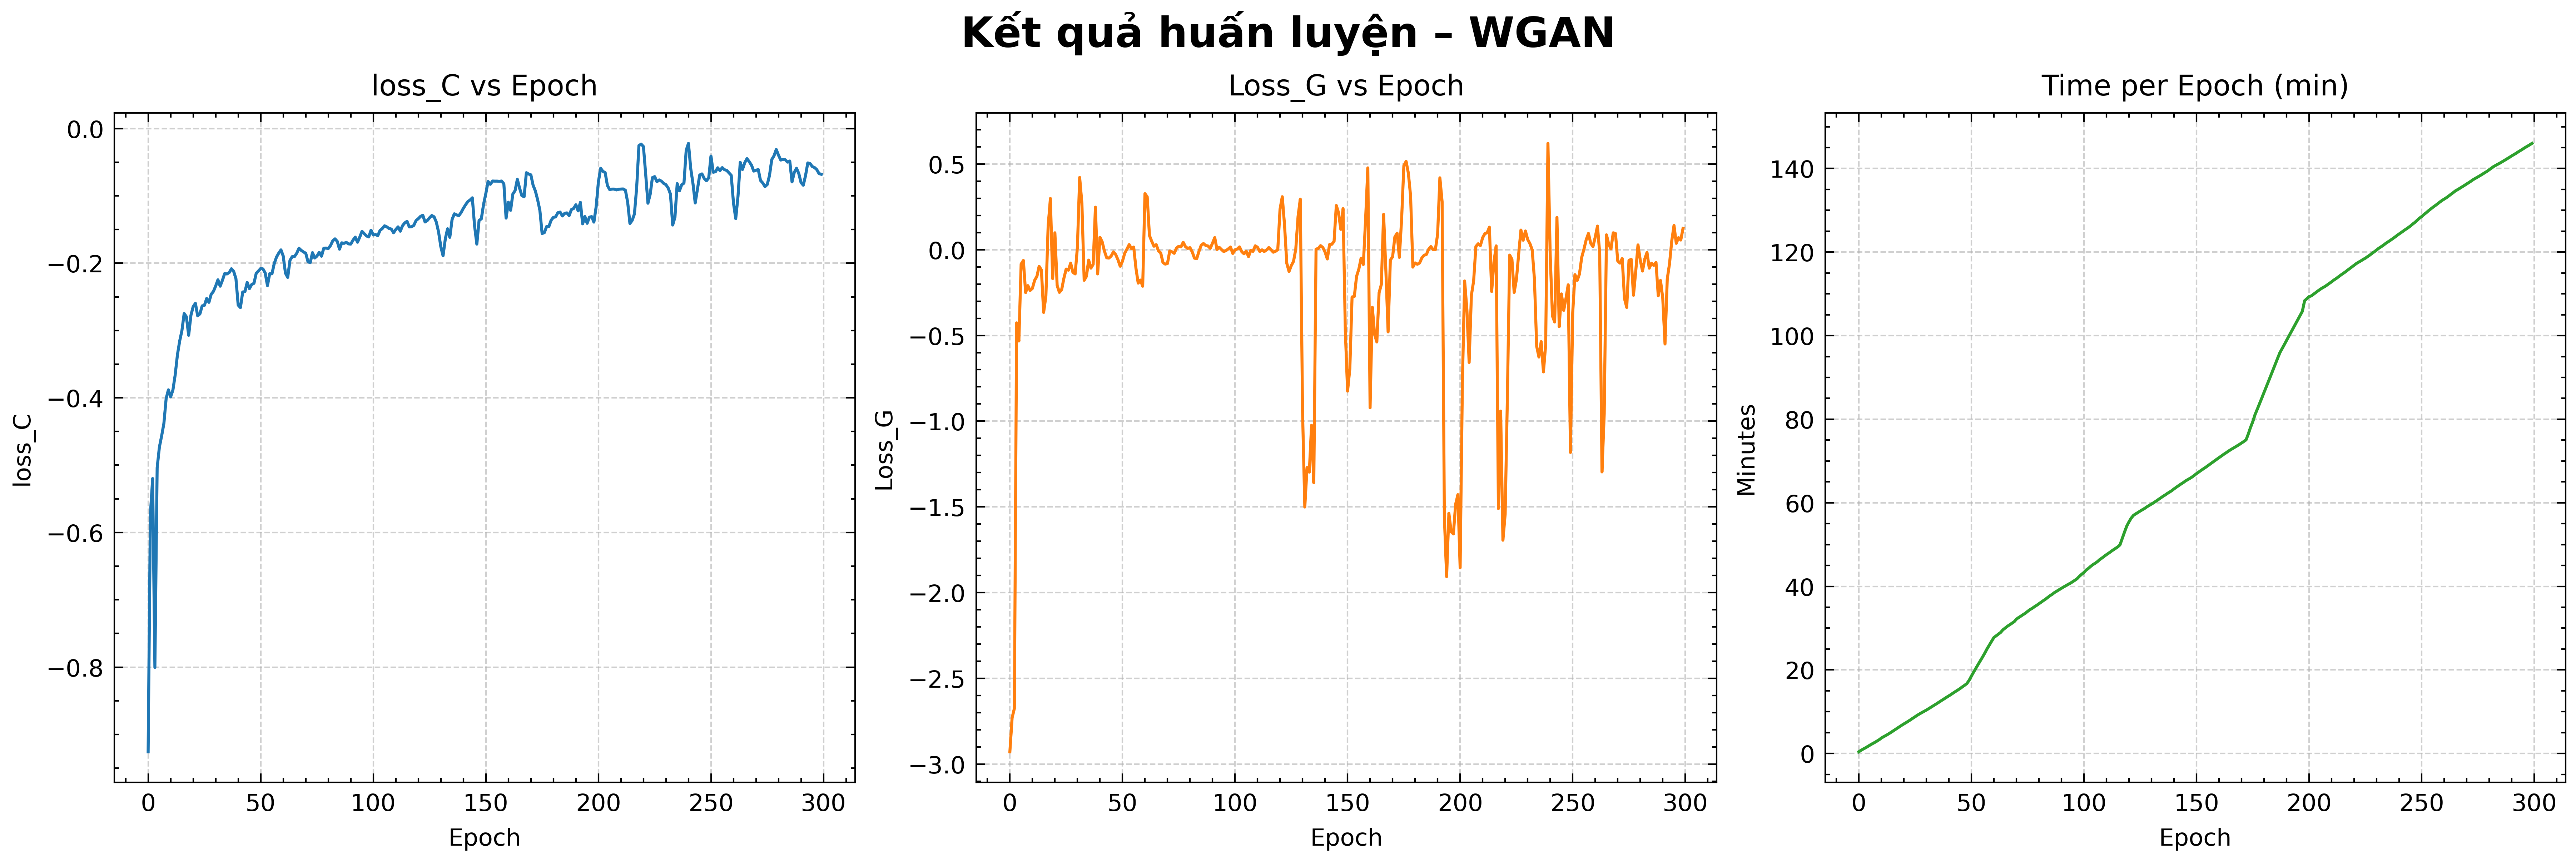

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


✅ Saved QGAN results to QGAN_training_results.pdf


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


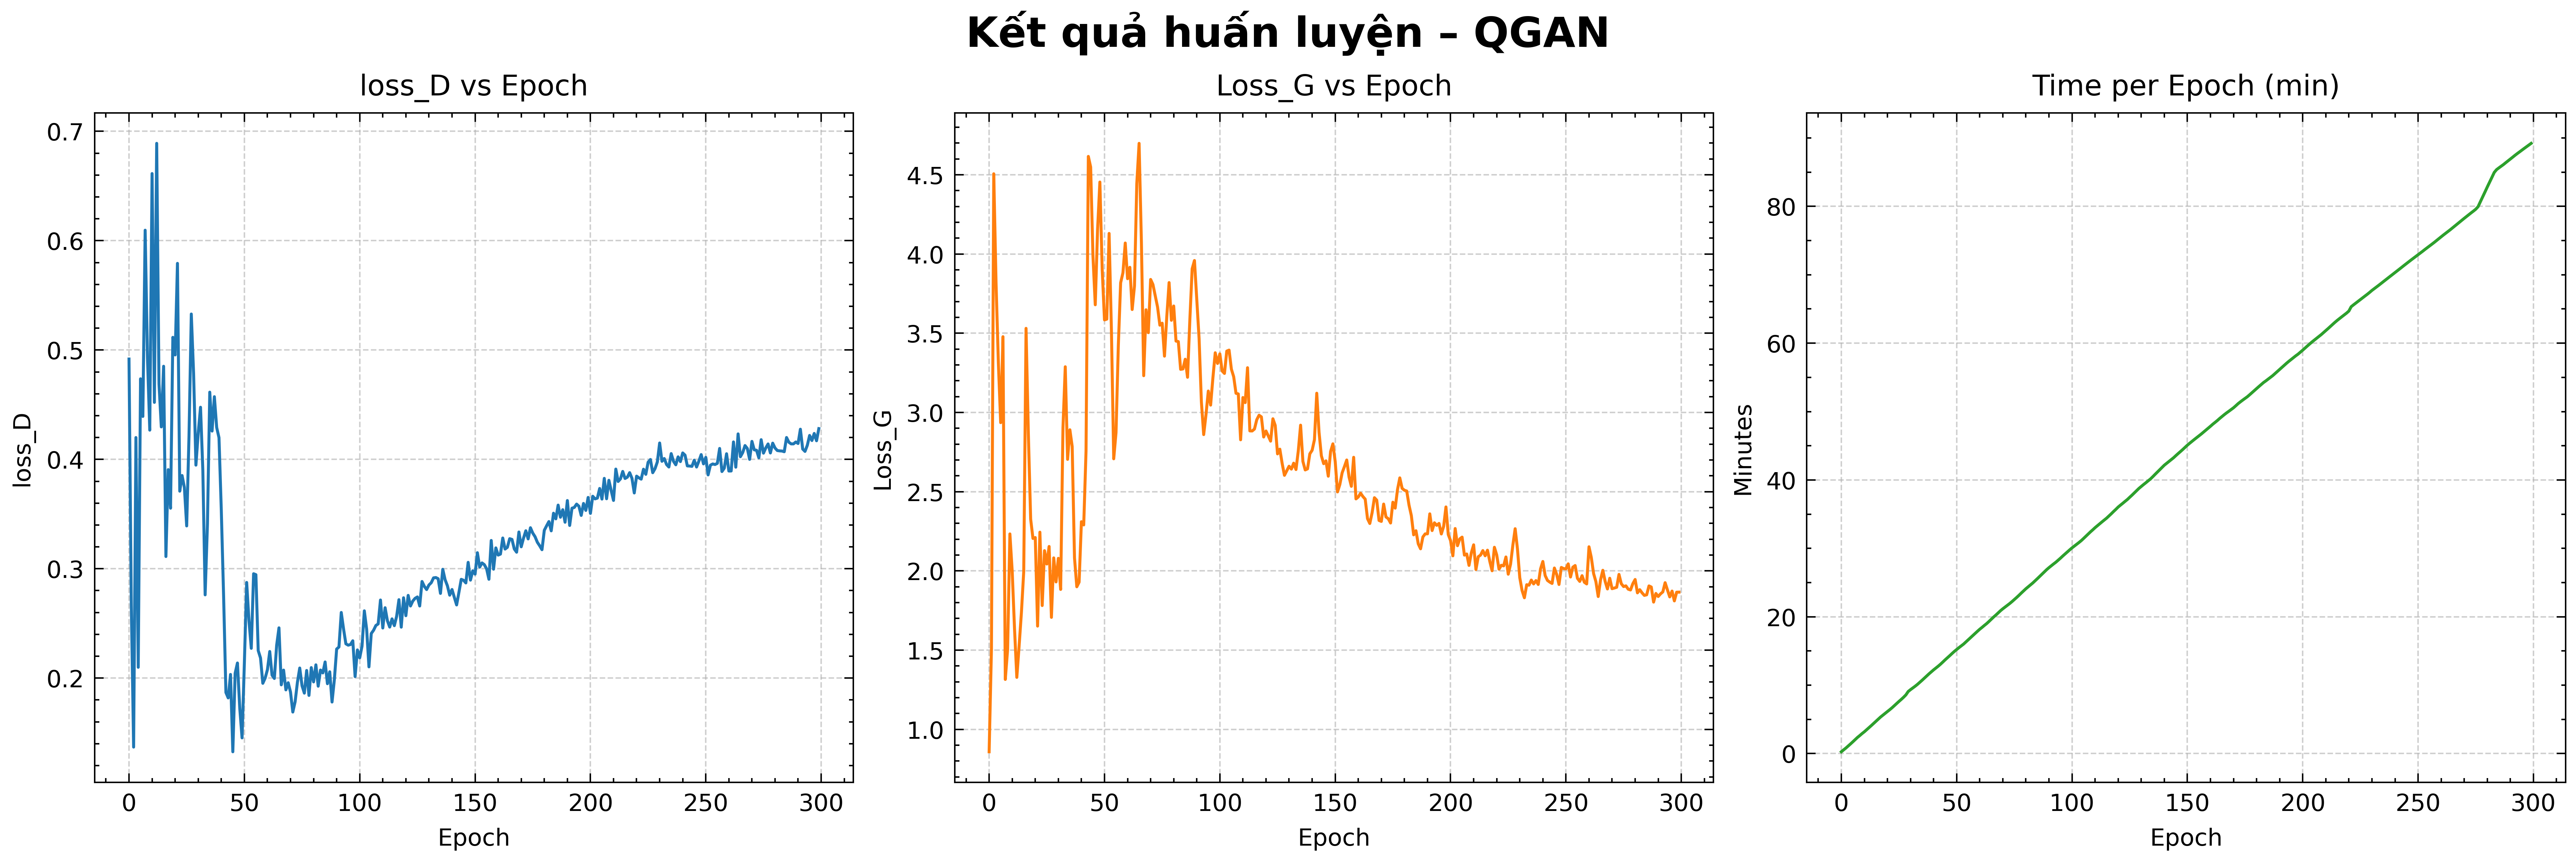

In [9]:
# File mapping: (filename, loss_type)
file_map = {
    'GAN': ('GAN_training.csv', 'loss_D'),
    'DCGAN': ('DCGAN_training.csv', 'loss_D'),
    'WGAN': ('WGAN_training.csv', 'loss_C'),
    'QGAN': ('QGAN_training.csv', 'loss_D'),
}

for model, (filename, loss_col) in file_map.items():
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        print(f"⚠️ Warning: file '{filename}' not found. Skipping {model}.")
        continue

    if not {'epoch', loss_col, 'loss_G', 'epoch_time_min'}.issubset(df.columns):
        print(f"⚠️ Warning: file '{filename}' missing required columns. Skipping {model}.")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

    # 1. Loss D/C
    axes[0].plot(df['epoch'], df[loss_col], color='#1f77b4')
    axes[0].set_title(f"{loss_col} vs Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel(loss_col)
    axes[0].grid(True, linestyle="--", alpha=0.6)

    # 2. Loss G
    axes[1].plot(df['epoch'], df['loss_G'], color='#ff7f0e')
    axes[1].set_title("Loss_G vs Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss_G")
    axes[1].grid(True, linestyle="--", alpha=0.6)

    # 3. Epoch Time
    axes[2].plot(df['epoch'], df['epoch_time_min'], color='#2ca02c')
    axes[2].set_title("Time per Epoch (min)")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Minutes")
    axes[2].grid(True, linestyle="--", alpha=0.6)

    # Main title
    fig.suptitle(f"Kết quả huấn luyện – {model}", fontsize=14, fontweight="bold")

    # Save figure
    output_path = f"{model}_training_results.pdf"
    plt.savefig(output_path, format='pdf', dpi=300)
    print(f"✅ Saved {model} results to {output_path}")

    plt.show()